# ODSB-17259: iOS Install Campaign CPI Trend (6h buckets)

**Campaigns:**
- `BhTo5PHbtcsuQwkh` — KR_New_install_260326_iOS (KOR)
- `VveaqT1OAcxlbXSv` — US_New_install_260326_iOS (USA)

**Period:** 2026-03-26 to 2026-03-30  
**Data:** `moloco-ae-view.athena.fact_dsp_all`, grouped by 6-hour buckets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
df = pd.read_csv('cpi_6h_trend.csv')
df['period_label'] = pd.to_datetime(df['period_label'])
df['cpi'] = pd.to_numeric(df['cpi'], errors='coerce')
df['spend_usd'] = pd.to_numeric(df['spend_usd'], errors='coerce')
df['installs'] = pd.to_numeric(df['installs'], errors='coerce')

# Cap extreme CPI outliers for readability (flag them separately)
CPI_CAP = 25
df['cpi_capped'] = df['cpi'].clip(upper=CPI_CAP)
df['cpi_outlier'] = df['cpi'] > CPI_CAP

kr = df[df['campaign_id'] == 'BhTo5PHbtcsuQwkh'].copy()
us = df[df['campaign_id'] == 'VveaqT1OAcxlbXSv'].copy()

print(f'KR rows: {len(kr)}, US rows: {len(us)}')
print(df.groupby('campaign_id')['cpi'].describe().round(2))

KR rows: 17, US rows: 17
                  count  mean   std  min   25%   50%   75%    max
campaign_id                                                      
BhTo5PHbtcsuQwkh   17.0  7.08  8.44  0.0  3.68  5.21  6.71  38.05
VveaqT1OAcxlbXSv   17.0  6.66  5.08  0.0  3.10  5.27  8.75  22.54


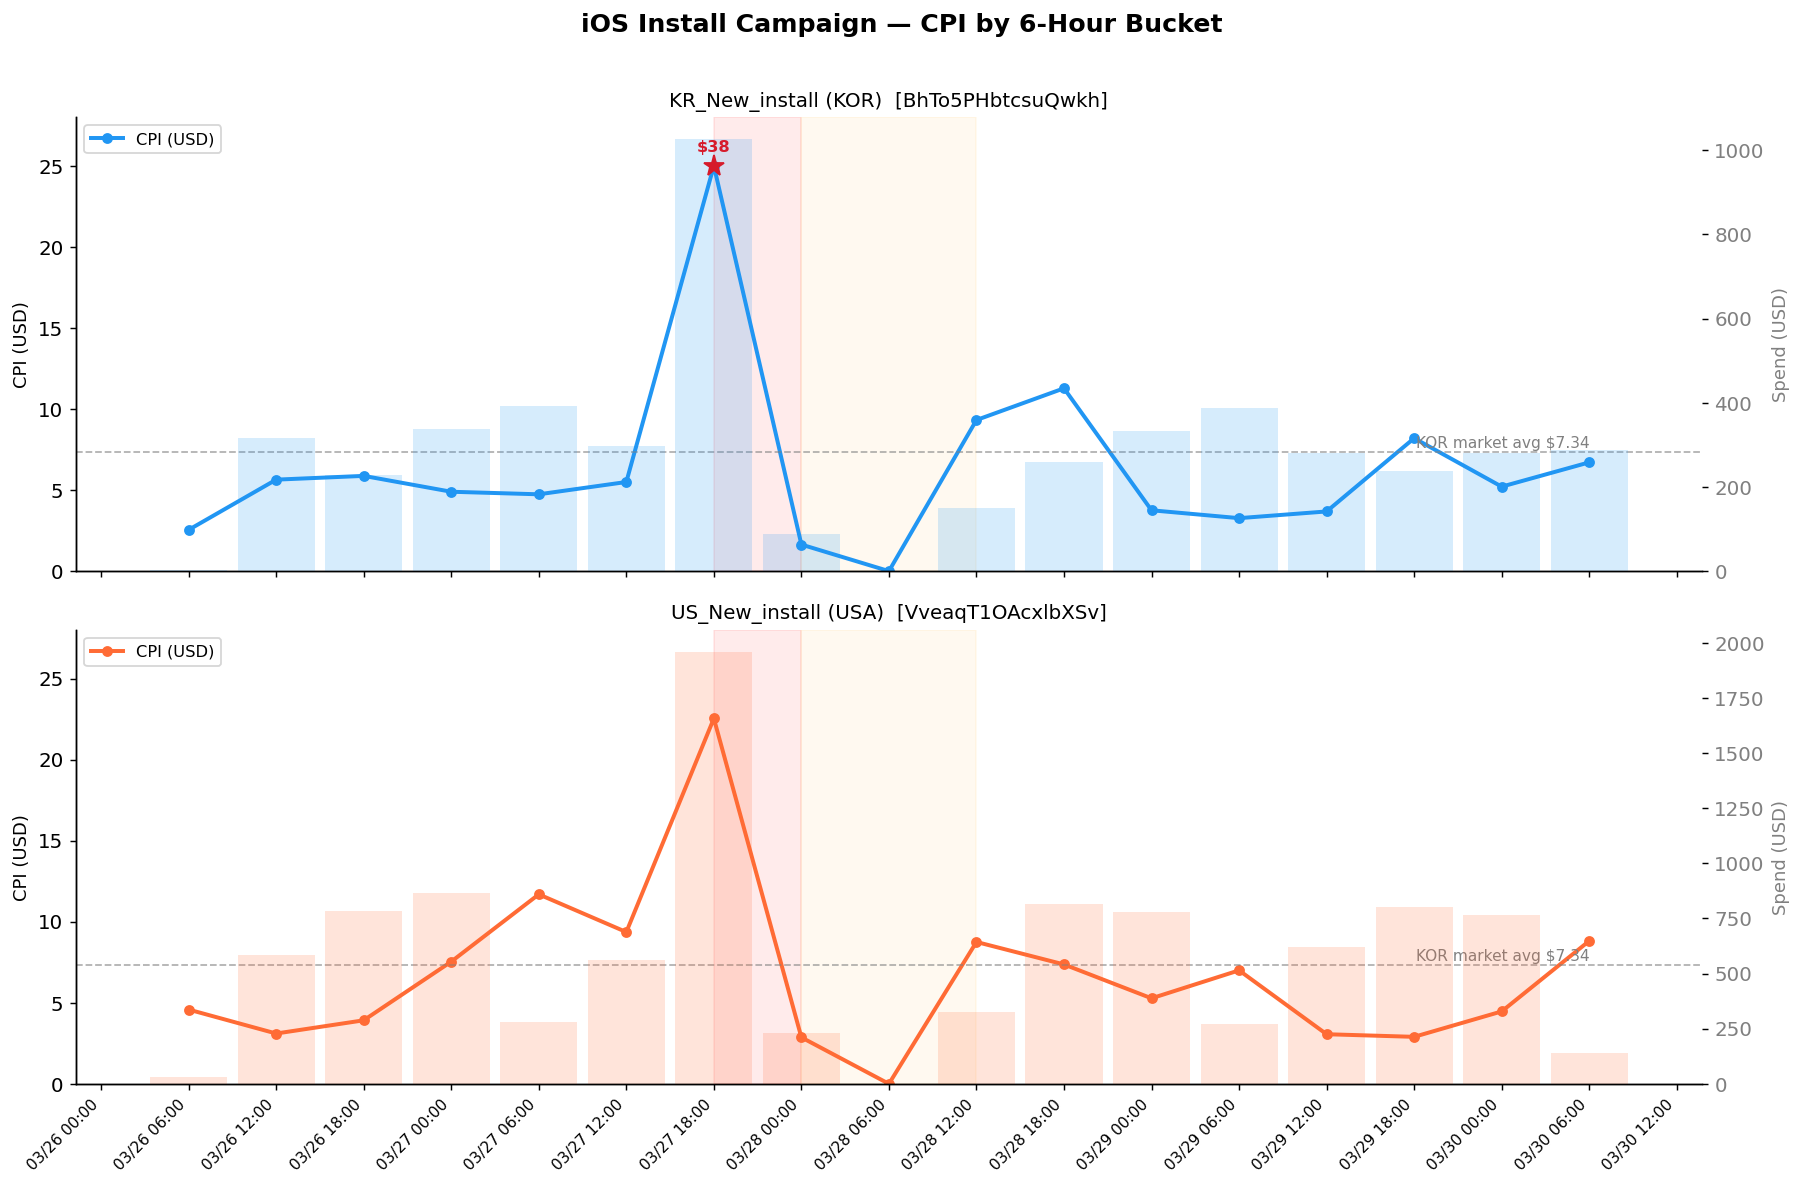

Saved: cpi_6h_trend.png


In [3]:
# ── Chart 1: CPI by 6h bucket (both campaigns, side by side) ──────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('iOS Install Campaign — CPI by 6-Hour Bucket', fontsize=14, fontweight='bold', y=1.01)

campaign_configs = [
    (kr, 'BhTo5PHbtcsuQwkh', 'KR_New_install (KOR)', '#2196F3'),
    (us, 'VveaqT1OAcxlbXSv', 'US_New_install (USA)', '#FF6B35'),
]

for ax, (data, cid, label, color) in zip(axes, campaign_configs):
    # Bar chart for spend
    ax2 = ax.twinx()
    ax2.bar(data['period_label'], data['spend_usd'], width=0.22,
            color=color, alpha=0.18, label='Spend (USD)')
    ax2.set_ylabel('Spend (USD)', color='grey', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='grey')
    ax2.spines['top'].set_visible(False)

    # CPI line (capped)
    ax.plot(data['period_label'], data['cpi_capped'],
            color=color, linewidth=2.2, marker='o', markersize=5, label='CPI (USD)')

    # Mark outliers with a star annotation
    for _, row in data[data['cpi_outlier']].iterrows():
        ax.annotate(f"${row['cpi']:.0f}",
                    xy=(row['period_label'], CPI_CAP),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='red', fontweight='bold')
        ax.plot(row['period_label'], CPI_CAP, marker='*', color='red', markersize=12)

    # Reference line: KOR broad market avg CPI ~$7.34
    ax.axhline(y=7.34, linestyle='--', color='grey', linewidth=1, alpha=0.6)
    ax.text(data['period_label'].iloc[-1], 7.6, 'KOR market avg $7.34',
            fontsize=8.5, color='grey', ha='right')

    ax.set_title(f'{label}  [{cid}]', fontsize=11, pad=6)
    ax.set_ylabel('CPI (USD)', fontsize=10)
    ax.set_ylim(0, CPI_CAP + 3)
    ax.legend(loc='upper left', fontsize=9)

    # Shade Mar 27 18:00–00:00 (spike window)
    ax.axvspan(pd.Timestamp('2026-03-27 18:00'), pd.Timestamp('2026-03-28 00:00'),
               alpha=0.08, color='red', label='Spike window')
    ax.axvspan(pd.Timestamp('2026-03-28 00:00'), pd.Timestamp('2026-03-28 12:00'),
               alpha=0.06, color='orange', label='Capping suppression')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8.5)

plt.tight_layout()
plt.savefig('cpi_6h_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: cpi_6h_trend.png')

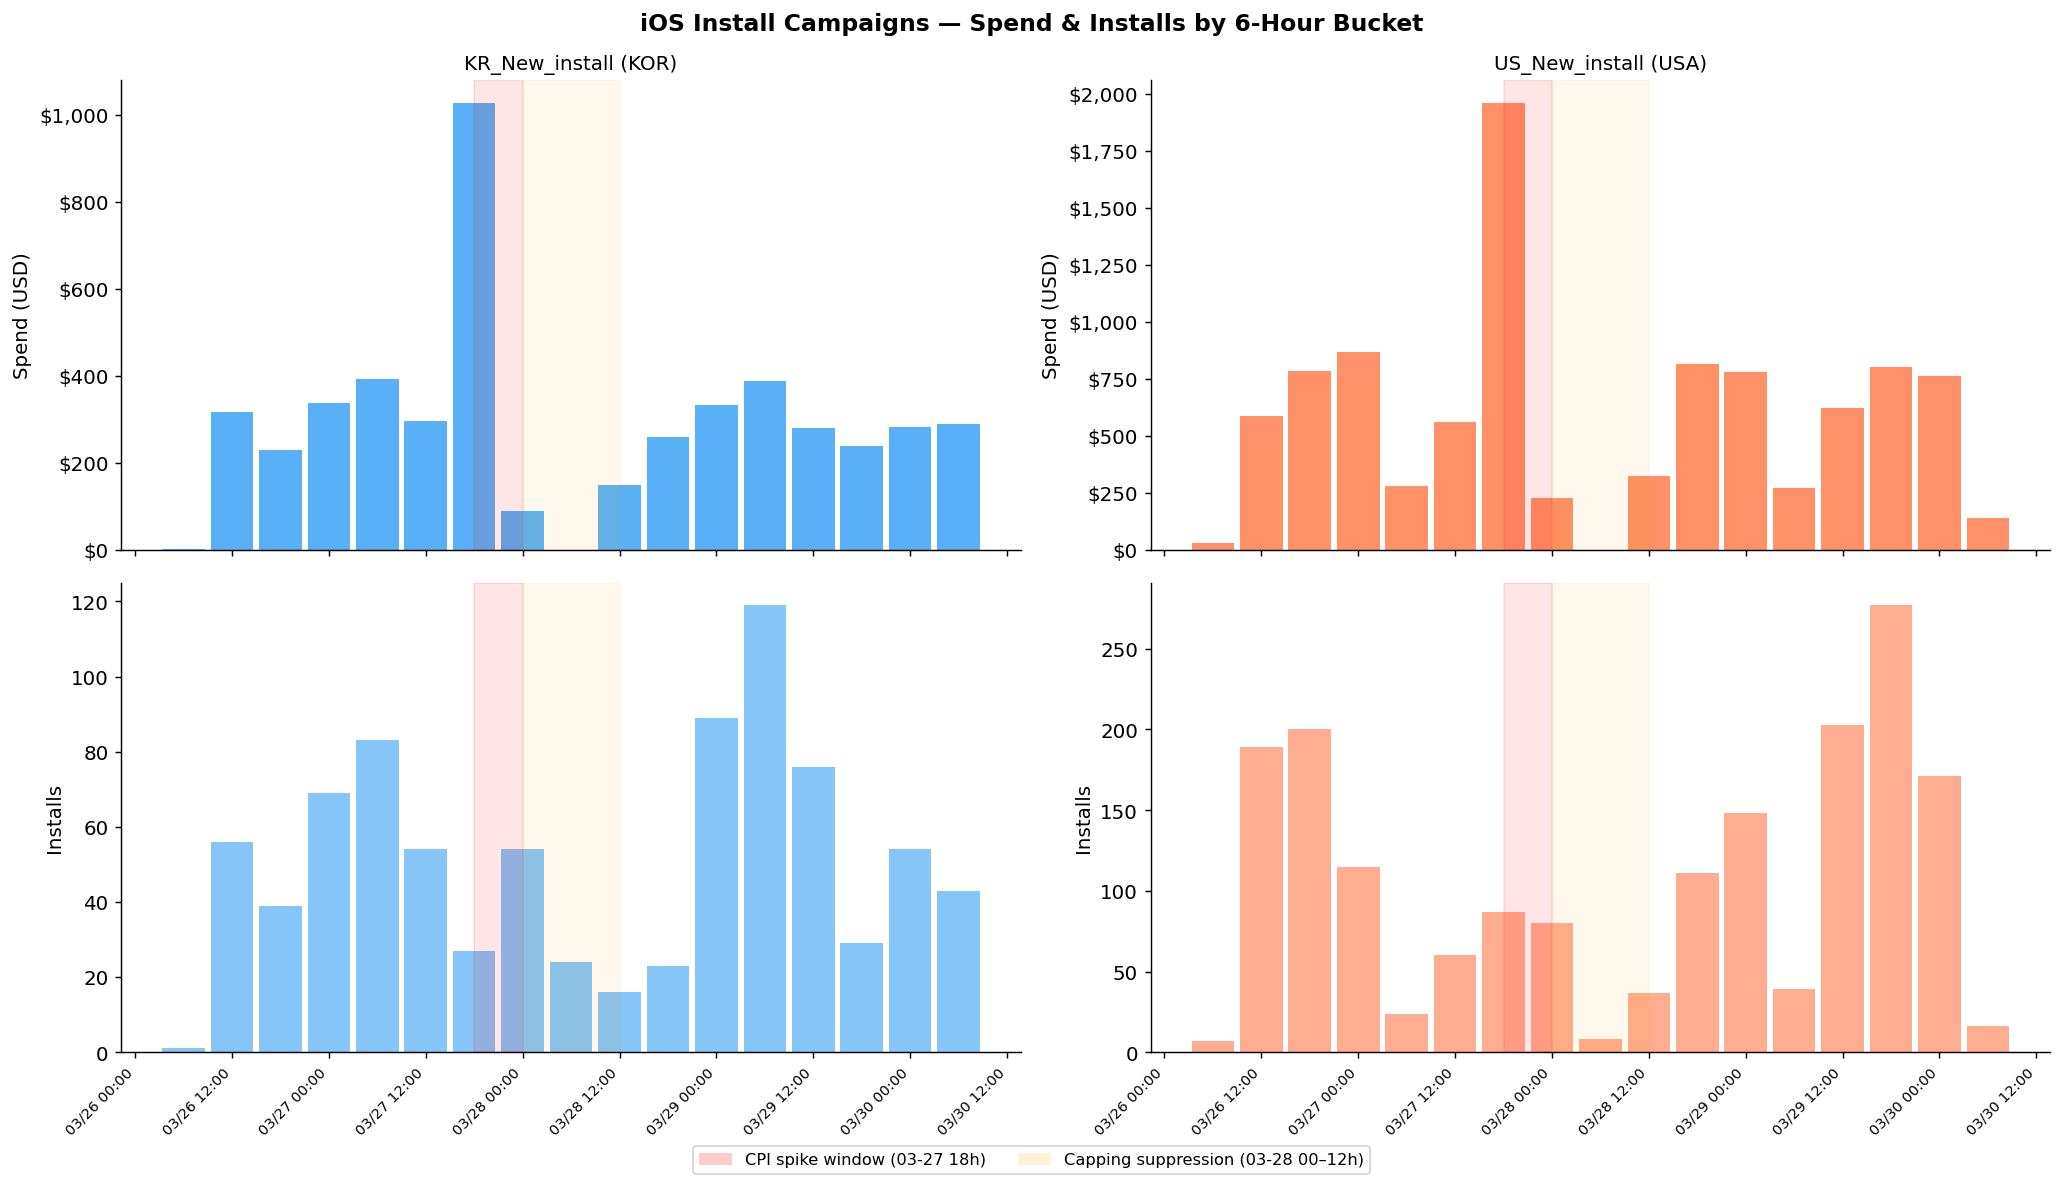

Saved: spend_installs_6h_trend.png


In [4]:
# ── Chart 2: Spend and Installs by 6h bucket ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
fig.suptitle('iOS Install Campaigns — Spend & Installs by 6-Hour Bucket', fontsize=13, fontweight='bold')

for col, (data, label, color) in enumerate([
    (kr, 'KR_New_install (KOR)', '#2196F3'),
    (us, 'US_New_install (USA)', '#FF6B35'),
]):
    ax_spend = axes[0][col]
    ax_inst  = axes[1][col]

    ax_spend.bar(data['period_label'], data['spend_usd'], width=0.22, color=color, alpha=0.75)
    ax_spend.set_title(label, fontsize=11)
    ax_spend.set_ylabel('Spend (USD)')
    ax_spend.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    ax_inst.bar(data['period_label'], data['installs'], width=0.22, color=color, alpha=0.55)
    ax_inst.set_ylabel('Installs')

    for ax in [ax_spend, ax_inst]:
        ax.axvspan(pd.Timestamp('2026-03-27 18:00'), pd.Timestamp('2026-03-28 00:00'),
                   alpha=0.1, color='red')
        ax.axvspan(pd.Timestamp('2026-03-28 00:00'), pd.Timestamp('2026-03-28 12:00'),
                   alpha=0.07, color='orange')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# Legend for shading
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.2, label='CPI spike window (03-27 18h)'),
    Patch(facecolor='orange', alpha=0.15, label='Capping suppression (03-28 00–12h)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('spend_installs_6h_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: spend_installs_6h_trend.png')

In [5]:
# ── Summary table ──────────────────────────────────────────────────────────
summary = df.groupby(['campaign_id', df['period_label'].dt.date]).agg(
    spend_usd=('spend_usd', 'sum'),
    installs=('installs', 'sum'),
).reset_index()
summary['cpi'] = (summary['spend_usd'] / summary['installs']).round(2)
summary.columns = ['campaign', 'date', 'spend_usd', 'installs', 'cpi']
summary['spend_usd'] = summary['spend_usd'].round(2)
print(summary.to_string(index=False))

        campaign       date  spend_usd  installs   cpi
BhTo5PHbtcsuQwkh 2026-03-26     547.58        96  5.70
BhTo5PHbtcsuQwkh 2026-03-27    2055.25       233  8.82
BhTo5PHbtcsuQwkh 2026-03-28     496.88       117  4.25
BhTo5PHbtcsuQwkh 2026-03-29    1240.06       313  3.96
BhTo5PHbtcsuQwkh 2026-03-30     569.79        97  5.87
VveaqT1OAcxlbXSv 2026-03-26    1401.91       396  3.54
VveaqT1OAcxlbXSv 2026-03-27    3669.42       286 12.83
VveaqT1OAcxlbXSv 2026-03-28    1370.20       236  5.81
VveaqT1OAcxlbXSv 2026-03-29    2477.26       667  3.71
VveaqT1OAcxlbXSv 2026-03-30     904.55       187  4.84
